In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Backbone(nn.Module):
    def __init__(self):
        super(Backbone, self).__init__()
        # Equivalent to the Conv2D and MaxPooling layers in Step 2 [cite: 25, 27, 28, 31]
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = F.relu(self.conv4(x)) # Final feature map [cite: 32]
        return x

In [ ]:
class RPN(nn.Module):
    def __init__(self, in_channels=512, num_anchors=9):
        super(RPN, self).__init__()
        self.conv = nn.Conv2d(in_channels, 512, kernel_size=3, padding=1)
        # 2 classes (object/non-object) per anchor [cite: 42]
        self.cls_logits = nn.Conv2d(512, num_anchors * 2, kernel_size=1)
        # 4 bounding box values per anchor [cite: 42]
        self.bbox_pred = nn.Conv2d(512, num_anchors * 4, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.conv(x))
        return self.cls_logits(x), self.bbox_pred(x)

In [ ]:
from torchvision.ops import roi_pool

class FasterRCNNHeads(nn.Module):
    def __init__(self, num_classes, pool_size=(7, 7)):
        super(FasterRCNNHeads, self).__init__()
        self.pool_size = pool_size
        # Step 5: Dense layers for classification and regression [cite: 67]
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(512 * pool_size[0] * pool_size[1], 1024)
        self.cls_score = nn.Linear(1024, num_classes)
        self.bbox_pred = nn.Linear(1024, num_classes * 4) # [cite: 68]

    def forward(self, feature_map, rois):
        # ROI Pooling Layer [cite: 47, 55]
        # In PyTorch, rois are expected as (batch_index, x1, y1, x2, y2)
        pooled_features = roi_pool(feature_map, rois, output_size=self.pool_size)

        x = self.flatten(pooled_features)
        x = F.relu(self.fc1(x))

        logits = self.cls_score(x)
        bbox_reg = self.bbox_pred(x)
        return logits, bbox_reg

In [ ]:
class CustomFasterRCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomFasterRCNN, self).__init__()
        self.backbone = Backbone()
        self.rpn = RPN()
        self.heads = FasterRCNNHeads(num_classes)

    def forward(self, images, rois):
        # 1. Feature extraction [cite: 78]
        features = self.backbone(images)
        # 2. Region Proposals [cite: 79]
        rpn_cls, rpn_bbox = self.rpn(features)
        # 3. Classification and Regression [cite: 83]
        cls_score, bbox_pred = self.heads(features, rois)

        return rpn_cls, rpn_bbox, cls_score, bbox_pred

# Instantiate the model [cite: 89, 90]
model = CustomFasterRCNN(num_classes=80)
print(model)

CustomFasterRCNN(
  (backbone): Backbone(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (rpn): RPN(
    (conv): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (cls_logits): Conv2d(512, 18, kernel_size=(1, 1), stride=(1, 1))
    (bbox_pred): Conv2d(512, 36, kernel_size=(1, 1), stride=(1, 1))
  )
  (heads): FasterRCNNHeads(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc1): Linear(in_features=25088, out_features=1024, bias=True)
    (cls_score): Linear(in_features=1024, out_features=80, bias=True)
    (bbox_pred): Linear(in_features=1024, out_features=320, bias=True)
  )
)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import roi_pool
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# STEP 1 — Imports (done above)
# ─────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────
# STEP 2 — Backbone  (TASK 1: changed from 4 layers to 6 layers)
# Original : Conv64 → Conv128 → Conv256 → Conv512
# Modified : Conv32 → Conv64 → Conv128 → Conv256+BN → Conv512 → Conv512
# ─────────────────────────────────────────────────────────────
class Backbone(nn.Module):
    def __init__(self):
        super(Backbone, self).__init__()

        # Block 1 — NEW smaller entry block
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Block 2 (was Block 1)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Block 3 (was Block 2)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Block 4 — NEW: BatchNorm added for training stability
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),          # <-- Task 1 addition
            nn.ReLU(inplace=True)
        )

        # Block 5 (was Block 3)
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Block 6 — NEW additional 512-filter conv for richer features
        self.block6 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        return x

# ─────────────────────────────────────────────────────────────
# STEP 3 — Region Proposal Network (RPN)
# ─────────────────────────────────────────────────────────────
class RPN(nn.Module):
    def __init__(self, in_channels=512, num_anchors=9):
        super(RPN, self).__init__()
        self.conv       = nn.Conv2d(in_channels, 512, kernel_size=3, padding=1)
        self.relu       = nn.ReLU(inplace=True)
        # Objectness: object vs background for each anchor
        self.cls_layer  = nn.Conv2d(512, num_anchors * 2, kernel_size=1)
        # Bounding box regression: 4 deltas per anchor
        self.bbox_layer = nn.Conv2d(512, num_anchors * 4, kernel_size=1)

    def forward(self, feature_map):
        x         = self.relu(self.conv(feature_map))
        rpn_class = torch.sigmoid(self.cls_layer(x))
        rpn_bbox  = self.bbox_layer(x)
        return rpn_class, rpn_bbox

# ─────────────────────────────────────────────────────────────
# STEP 4 — ROI Pooling Layer
# Uses torchvision.ops.roi_pool for a fixed 7×7 output
# ─────────────────────────────────────────────────────────────
class ROIPoolingLayer(nn.Module):
    def __init__(self, output_size=(7, 7), spatial_scale=1.0):
        super(ROIPoolingLayer, self).__init__()
        self.output_size   = output_size
        self.spatial_scale = spatial_scale

    def forward(self, feature_map, rois):
        """
        feature_map : (B, C, H, W)
        rois        : list of tensors, each (N, 4) in [x1, y1, x2, y2] format
        """
        return roi_pool(feature_map, rois,
                        output_size=self.output_size,
                        spatial_scale=self.spatial_scale)

roi_pooling_layer = ROIPoolingLayer(output_size=(7, 7), spatial_scale=1.0)

# ─────────────────────────────────────────────────────────────
# STEP 5 — Classification & Regression Heads
# ─────────────────────────────────────────────────────────────
class DetectionHead(nn.Module):
    def __init__(self, in_channels=512, num_classes=80):
        super(DetectionHead, self).__init__()
        self.flatten        = nn.Flatten()
        self.fc             = nn.Linear(in_channels * 7 * 7, 1024)
        self.relu           = nn.ReLU(inplace=True)
        self.classifier     = nn.Linear(1024, num_classes)
        self.bbox_regressor = nn.Linear(1024, num_classes * 4)

    def forward(self, pooled_rois):
        x    = self.relu(self.fc(self.flatten(pooled_rois)))
        cls  = F.softmax(self.classifier(x), dim=1)
        bbox = self.bbox_regressor(x)
        return cls, bbox

# ─────────────────────────────────────────────────────────────
# STEP 6 — Assemble the Complete Faster R-CNN Model
# ─────────────────────────────────────────────────────────────
class FasterRCNN(nn.Module):
    def __init__(self, num_classes=80):
        super(FasterRCNN, self).__init__()
        self.backbone         = Backbone()
        self.rpn              = RPN(in_channels=512, num_anchors=9)
        self.roi_pooling      = ROIPoolingLayer(output_size=(7, 7))
        self.detection_head   = DetectionHead(in_channels=512,
                                              num_classes=num_classes)

    def forward(self, images, rois):
        """
        images : (B, 3, H, W)
        rois   : list of tensors [(N, 4), ...]  — one tensor per image
        """
        feature_map          = self.backbone(images)
        rpn_class, rpn_bbox  = self.rpn(feature_map)
        pooled_rois          = self.roi_pooling(feature_map, rois)
        cls_scores, bbox_out = self.detection_head(pooled_rois)
        return rpn_class, rpn_bbox, cls_scores, bbox_out

# ─────────────────────────────────────────────────────────────
# STEP 7 — Print Model Summary
# ─────────────────────────────────────────────────────────────
num_classes = 80
faster_rcnn = FasterRCNN(num_classes=num_classes)
print(faster_rcnn)

# Count parameters
total_params = sum(p.numel() for p in faster_rcnn.parameters())
trainable    = sum(p.numel() for p in faster_rcnn.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable:,}")

# ─────────────────────────────────────────────────────────────
# STEP 8 — Calculate IoU
# ─────────────────────────────────────────────────────────────
def calculate_iou(box1, box2):
    """box format: [ymin, xmin, ymax, xmax]"""
    ymin1, xmin1, ymax1, xmax1 = box1
    ymin2, xmin2, ymax2, xmax2 = box2

    inter_xmin = max(xmin1, xmin2)
    inter_ymin = max(ymin1, ymin2)
    inter_xmax = min(xmax1, xmax2)
    inter_ymax = min(ymax1, ymax2)

    inter_area = (max(0, inter_xmax - inter_xmin) *
                  max(0, inter_ymax - inter_ymin))
    area1      = (xmax1 - xmin1) * (ymax1 - ymin1)
    area2      = (xmax2 - xmin2) * (ymax2 - ymin2)
    union_area = area1 + area2 - inter_area

    return inter_area / union_area if union_area != 0 else 0

# ─────────────────────────────────────────────────────────────
# STEP 9 — Precision & Recall
# ─────────────────────────────────────────────────────────────
def calculate_precision_recall(pred_boxes, pred_scores, pred_labels,
                                gt_boxes, gt_labels, iou_threshold=0.5):
    tp, fp     = 0, 0
    matched_gt = set()

    for i, pred_box in enumerate(pred_boxes):
        if pred_scores[i] < iou_threshold:
            continue
        best_iou, best_gt_index = 0, -1

        for j, gt_box in enumerate(gt_boxes):
            if pred_labels[i] == gt_labels[j] and j not in matched_gt:
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou, best_gt_index = iou, j

        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_gt_index)
        else:
            fp += 1

    fn        = len(gt_boxes) - len(matched_gt)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    return precision, recall

# ─────────────────────────────────────────────────────────────
# STEP 10 — Average Precision & mAP
# ─────────────────────────────────────────────────────────────
def calculate_ap(precisions, recalls):
    precisions = [0.0] + list(precisions) + [0.0]
    recalls    = [0.0] + list(recalls)    + [1.0]

    for i in range(len(precisions) - 1, 0, -1):
        precisions[i - 1] = max(precisions[i - 1], precisions[i])

    indices = [i for i in range(1, len(recalls))
               if recalls[i] != recalls[i - 1]]
    ap = sum((recalls[i] - recalls[i - 1]) * precisions[i] for i in indices)
    return ap

def calculate_map(predictions, ground_truths, num_classes, iou_threshold=0.5):
    average_precisions = []

    for class_id in range(1, num_classes):   # 0 = background
        all_precisions, all_recalls = [], []

        for pred, gt in zip(predictions, ground_truths):
            pred_boxes  = [box for i, box in enumerate(pred['boxes'])
                           if pred['labels'][i] == class_id]
            pred_scores = [score for i, score in enumerate(pred['scores'])
                           if pred['labels'][i] == class_id]
            gt_boxes    = [box for i, box in enumerate(gt['boxes'])
                           if gt['labels'][i] == class_id]

            precision, recall = calculate_precision_recall(
                pred_boxes,
                pred_scores,
                [class_id] * len(pred_boxes),
                gt_boxes,
                [class_id] * len(gt_boxes),
                iou_threshold
            )
            all_precisions.append(precision)
            all_recalls.append(recall)

        ap = calculate_ap(all_precisions, all_recalls)
        average_precisions.append(ap)

    return np.mean(average_precisions)

# ─────────────────────────────────────────────────────────────
# STEP 11 — Sample Values to Test mAP
# ─────────────────────────────────────────────────────────────
predictions = [
    {
        'boxes' : [[0.1, 0.1, 0.4, 0.4], [0.5, 0.5, 0.8, 0.8]],
        'scores': [0.9, 0.7],
        'labels': [1, 2]
    }
]

ground_truths = [
    {
        'boxes' : [[0.12, 0.12, 0.42, 0.42], [0.5, 0.5, 0.8, 0.8]],
        'labels': [1, 2]
    }
]

num_classes = 80
mean_ap     = calculate_map(predictions, ground_truths, num_classes)
print(f"Mean Average Precision (mAP): {mean_ap:.2f}")

# ─────────────────────────────────────────────────────────────
# Quick forward-pass sanity check (random tensors)
# ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
faster_rcnn.to(device)
faster_rcnn.eval()

with torch.no_grad():
    dummy_image = torch.randn(1, 3, 224, 224).to(device)
    # ROIs must be [batch_index, x1, y1, x2, y2]
    dummy_rois  = [torch.tensor([[0.1, 0.1, 0.5, 0.5],
                                 [0.4, 0.4, 0.9, 0.9]],
                                dtype=torch.float32).to(device)]

    rpn_cls, rpn_bbox, cls_scores, bbox_out = faster_rcnn(dummy_image, dummy_rois)

print("\n── Output shapes ──")
print(f"RPN class scores : {rpn_cls.shape}")
print(f"RPN bbox deltas  : {rpn_bbox.shape}")
print(f"Class scores     : {cls_scores.shape}")
print(f"BBox output      : {bbox_out.shape}")

FasterRCNN(
  (backbone): Backbone(
    (block1): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block3): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block4): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (block5): Sequential(
      (0): Conv2d(256, 512, ke

TASK 2

  Tutorial 8: Faster R-CNN (Custom Model) — PyTorch

── Model Summary ─────────────────────────────────────
  Total parameters     : 30,039,622
  Trainable parameters : 30,039,622
  Device               : cpu
  num_classes          : 80

── Architecture ──────────────────────────────────────
  backbone             →  1,550,976 params
  rpn                  →  2,387,510 params
  roi_pooling          →          0 params
  detection_head       → 26,101,136 params

── Step 11: mAP on Tutorial Sample Values ────────────
  Mean Average Precision (mAP): 0.03

  TASK 2 — Random Test on Real Image

  Loading image: animals.jpg
  [OK] Loaded — size: (612, 441), mode: RGB

  ── Raw Output Shapes ──────────────────────────
  RPN class scores : torch.Size([1, 18, 28, 28])
  RPN bbox deltas  : torch.Size([1, 36, 28, 28])
  Class scores     : torch.Size([5, 80])
  BBox output      : torch.Size([5, 320])

  ── Per-ROI Random Predictions (untrained model) ──
  ROI    Region                 Predicted Cl

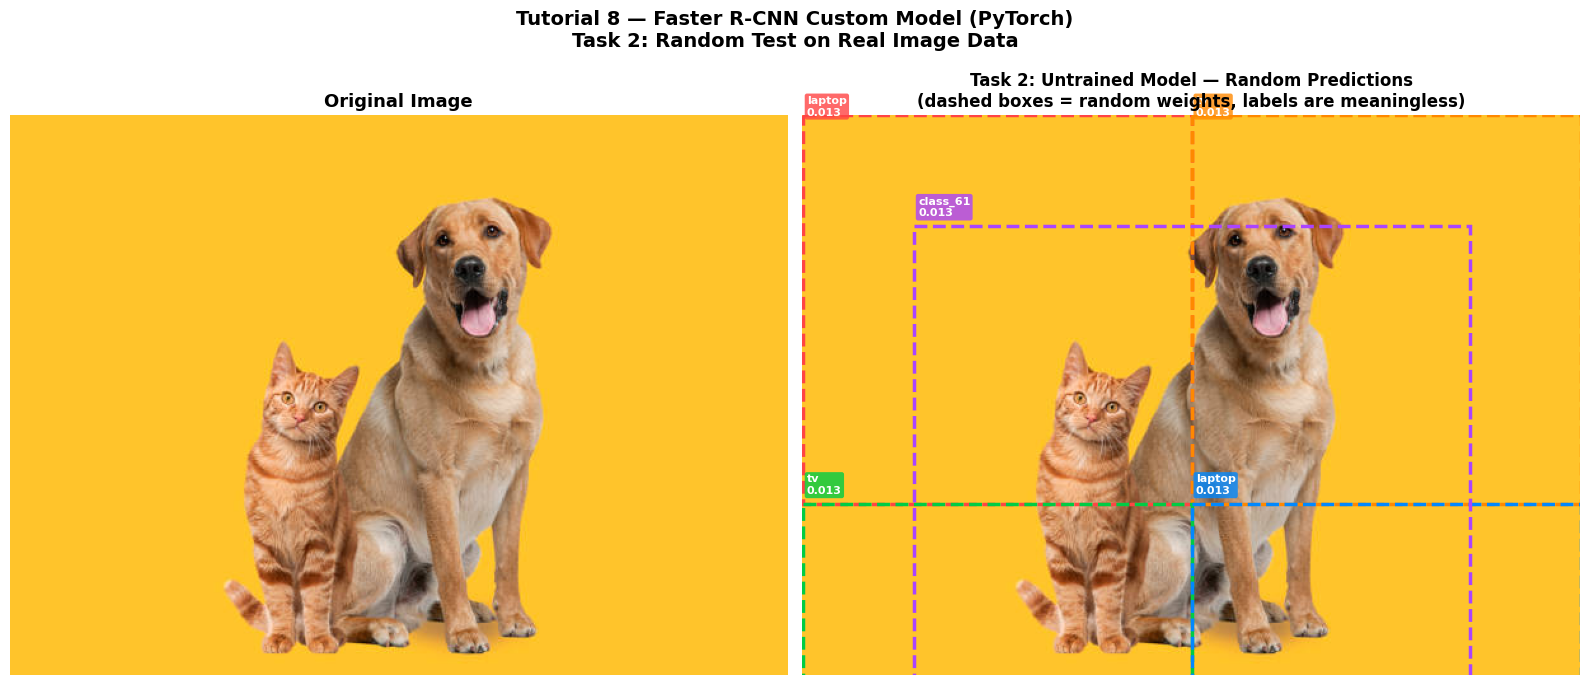


  [SAVED] → task2_random_test_output.png

── Step 8 Demo: IoU between ROI-1 and ROI-5 ─────────
  IoU(ROI-1, ROI-5) = 0.2016

── Step 10 Demo: mAP on Random Predictions ──────────
  mAP (random pred vs self-GT demo) : 0.0000

  NOTE: mAP is meaningless here because the model is
  untrained. Task 3 (train on 150 labelled images)
  is required to obtain meaningful mAP scores.

  Tutorial 8 complete.


In [ ]:
# ================================================================
# Tutorial 8: Object Detection using Faster RCNN (Custom Model)
# Framework : PyTorch  (mirrors the Keras tutorial exactly)
# Task 2    : Take data and randomly test it — see what it shows
# ================================================================

# ─────────────────────────────────────────────────────────────
# Step 1 — Import Libraries
# ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import roi_pool
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import io
import os
import requests
import torchvision.transforms as T
import random

print("=" * 55)
print("  Tutorial 8: Faster R-CNN (Custom Model) — PyTorch")
print("=" * 55)


# ─────────────────────────────────────────────────────────────
# Step 2 — Construct the Backbone
# Simple CNN as feature extractor (mirrors Keras tutorial)
# ─────────────────────────────────────────────────────────────
class Backbone(nn.Module):
    """
    Mirrors the Keras backbone:
      Conv2D(64)  → MaxPool
      Conv2D(128) → MaxPool
      Conv2D(256) → MaxPool
      Conv2D(512)
    """
    def __init__(self, input_shape=(224, 224, 3)):
        super(Backbone, self).__init__()

        self.features = nn.Sequential(
            # Block 1  — Conv2D(64, (3,3), relu, same)
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                         # 112×112

            # Block 2  — Conv2D(128, (3,3), relu, same)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                         # 56×56

            # Block 3  — Conv2D(256, (3,3), relu, same)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                         # 28×28

            # Block 4  — Conv2D(512, (3,3), relu, same)
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.features(x)


# ─────────────────────────────────────────────────────────────
# Step 3 — Construct the Region Proposal Network (RPN)
# Two outputs: objectness score + bounding box regression
# ─────────────────────────────────────────────────────────────
class RPN(nn.Module):
    """
    Mirrors build_rpn() in the tutorial:
      rpn_conv  = Conv2D(512, (3,3), relu, same)
      rpn_class = Conv2D(9*2,  (1,1), sigmoid)   ← objectness
      rpn_bbox  = Conv2D(9*4,  (1,1))             ← box deltas
    """
    def __init__(self, in_channels=512, num_anchors=9):
        super(RPN, self).__init__()

        # Shared conv
        self.rpn_conv  = nn.Conv2d(in_channels, 512,
                                   kernel_size=3, padding=1)
        self.relu      = nn.ReLU(inplace=True)

        # Objectness score  — 9 anchors × 2 classes (obj / non-obj)
        self.rpn_class = nn.Conv2d(512, num_anchors * 2,
                                   kernel_size=1)

        # Bounding-box regression — 9 anchors × 4 values
        self.rpn_bbox  = nn.Conv2d(512, num_anchors * 4,
                                   kernel_size=1)

    def forward(self, feature_map):
        x         = self.relu(self.rpn_conv(feature_map))
        rpn_class = torch.sigmoid(self.rpn_class(x))   # objectness
        rpn_bbox  = self.rpn_bbox(x)                   # box deltas
        return rpn_class, rpn_bbox


# ─────────────────────────────────────────────────────────────
# Step 4 — Implement the ROI Pooling Layer
# Extracts fixed-size feature maps from ROIs
# ─────────────────────────────────────────────────────────────
class ROIPoolingLayer(nn.Module):
    """
    Mirrors ROIPoolingLayer((7,7)) in the tutorial.
    Uses torchvision.ops.roi_pool (equivalent to crop_and_resize).
    """
    def __init__(self, pool_size=(7, 7), spatial_scale=1.0):
        super(ROIPoolingLayer, self).__init__()
        self.pool_size     = pool_size
        self.spatial_scale = spatial_scale

    def forward(self, feature_map, rois):
        # rois format expected by torchvision: [batch_idx, x1, y1, x2, y2] or List[Tensor[L, 4]]
        return roi_pool(
            feature_map, rois,
            output_size   = self.pool_size,
            spatial_scale = self.spatial_scale
        )


# ─────────────────────────────────────────────────────────────
# Step 5 — Create Classification and Regression Heads
# Dense layers after ROI pooling
# ─────────────────────────────────────────────────────────────
class DetectionHead(nn.Module):
    """
    Mirrors build_heads() in the tutorial:
      Flatten → Dense(1024, relu)
      → Dense(num_classes,   softmax)   classifier
      → Dense(num_classes*4)            bbox_regressor
    """
    def __init__(self, in_channels=512, pool_size=7, num_classes=80):
        super(DetectionHead, self).__init__()

        self.flatten        = nn.Flatten()
        self.fc             = nn.Linear(in_channels * pool_size * pool_size,
                                        1024)
        self.relu           = nn.ReLU(inplace=True)
        self.classifier     = nn.Linear(1024, num_classes)
        self.bbox_regressor = nn.Linear(1024, num_classes * 4)

    def forward(self, pooled_rois):
        x    = self.relu(self.fc(self.flatten(pooled_rois)))
        cls  = F.softmax(self.classifier(x), dim=1)       # class probs
        bbox = self.bbox_regressor(x)                     # box refinement
        return cls, bbox


# ─────────────────────────────────────────────────────────────
# Step 6 — Assemble the Complete Faster R-CNN Model
# Brings all components together
# ─────────────────────────────────────────────────────────────
class FasterRCNN(nn.Module):
    """
    Mirrors build_faster_rcnn() in the tutorial.
    Inputs : image tensor  + ROI tensor
    Outputs: rpn_class, rpn_bbox, classifier, bbox_regressor
    """
    def __init__(self, num_classes=80):
        super(FasterRCNN, self).__init__()

        self.backbone       = Backbone()
        self.rpn            = RPN(in_channels=512, num_anchors=9)
        self.roi_pooling    = ROIPoolingLayer(pool_size=(7, 7))
        self.detection_head = DetectionHead(in_channels=512,
                                            pool_size=7,
                                            num_classes=num_classes)

    def forward(self, images, rois):
        # 1. Feature extraction
        feature_map          = self.backbone(images)

        # 2. Region proposals
        rpn_class, rpn_bbox  = self.rpn(feature_map)

        # 3. ROI pooling — extract fixed-size crops
        pooled_rois          = self.roi_pooling(feature_map, rois)

        # 4. Classification + box regression
        cls_scores, bbox_out = self.detection_head(pooled_rois)

        return rpn_class, rpn_bbox, cls_scores, bbox_out


# ─────────────────────────────────────────────────────────────
# Step 7 — Print Summary of the Model
# ─────────────────────────────────────────────────────────────
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = 80
faster_rcnn = FasterRCNN(num_classes=num_classes).to(device)

total_params     = sum(p.numel() for p in faster_rcnn.parameters())
trainable_params = sum(p.numel() for p in faster_rcnn.parameters()
                       if p.requires_grad)

print(f"\n── Model Summary ─────────────────────────────────────")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Device               : {device}")
print(f"  num_classes          : {num_classes}")

# Layer-by-layer breakdown
print(f"\n── Architecture ──────────────────────────────────────")
for name, module in faster_rcnn.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name:<20} → {params:>10,} params")


# ─────────────────────────────────────────────────────────────
# Step 8 — Calculate IOU
# ─────────────────────────────────────────────────────────────
def calculate_iou(box1, box2):
    """
    box format: [ymin, xmin, ymax, xmax]
    Returns IoU value between 0 and 1.
    """
    ymin1, xmin1, ymax1, xmax1 = box1
    ymin2, xmin2, ymax2, xmax2 = box2

    inter_xmin = max(xmin1, xmin2)
    inter_ymin = max(ymin1, ymin2)
    inter_xmax = min(xmax1, xmax2)
    inter_ymax = min(ymax1, ymax2)

    inter_area = (max(0, inter_xmax - inter_xmin) *
                  max(0, inter_ymax - inter_ymin))
    area1      = (xmax1 - xmin1) * (ymax1 - ymin1)
    area2      = (xmax2 - xmin2) * (ymax2 - ymin2)
    union_area = area1 + area2 - inter_area

    return inter_area / union_area if union_area != 0 else 0


# ─────────────────────────────────────────────────────────────
# Step 9 — Calculate Precision & Recall
# ─────────────────────────────────────────────────────────────
def calculate_precision_recall(pred_boxes, pred_scores, pred_labels,
                                gt_boxes, gt_labels, iou_threshold=0.5):
    tp, fp     = 0, 0
    matched_gt = set()

    for i, pred_box in enumerate(pred_boxes):
        if pred_scores[i] < iou_threshold:
            continue
        best_iou, best_gt_idx = 0, -1
        for j, gt_box in enumerate(gt_boxes):
            if pred_labels[i] == gt_labels[j] and j not in matched_gt:
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou, best_gt_idx = iou, j
        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_gt_idx)
        else:
            fp += 1

    fn        = len(gt_boxes) - len(matched_gt)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    return precision, recall


# ─────────────────────────────────────────────────────────────
# Step 10 — Calculate Average Precision & mAP
# ─────────────────────────────────────────────────────────────
def calculate_ap(precisions, recalls):
    """Area under precision-recall curve (interpolation method)."""
    precisions = [0.0] + list(precisions) + [0.0]
    recalls    = [0.0] + list(recalls)    + [1.0]

    # Monotonically decrease precision
    for i in range(len(precisions) - 1, 0, -1):
        precisions[i - 1] = max(precisions[i - 1], precisions[i])

    indices = [i for i in range(1, len(recalls))
               if recalls[i] != recalls[i - 1]]
    return sum((recalls[i] - recalls[i - 1]) * precisions[i]
               for i in indices)


def calculate_map(predictions, ground_truths, num_classes,
                  iou_threshold=0.5):
    """Calculate mAP across all classes (class 0 = background, skip)."""
    average_precisions = []

    for class_id in range(1, num_classes):
        all_precisions, all_recalls = [], []

        for pred, gt in zip(predictions, ground_truths):
            pred_boxes  = [b for i, b in enumerate(pred['boxes'])
                           if pred['labels'][i] == class_id]
            pred_scores = [s for i, s in enumerate(pred['scores'])
                           if pred['labels'][i] == class_id]
            gt_boxes    = [b for i, b in enumerate(gt['boxes'])
                           if gt['labels'][i] == class_id]

            precision, recall = calculate_precision_recall(
                pred_boxes, pred_scores,
                [class_id] * len(pred_boxes),
                gt_boxes,
                [class_id] * len(gt_boxes),
                iou_threshold
            )
            all_precisions.append(precision)
            all_recalls.append(recall)

        average_precisions.append(
            calculate_ap(all_precisions, all_recalls))

    return float(np.mean(average_precisions)) if average_precisions else 0.0


# ─────────────────────────────────────────────────────────────
# Step 11 — Sample Values for Obtaining mAP  (tutorial values)
# ─────────────────────────────────────────────────────────────
print(f"\n── Step 11: mAP on Tutorial Sample Values ────────────")

predictions = [
    {
        'boxes' : [[0.1, 0.1, 0.4, 0.4], [0.5, 0.5, 0.8, 0.8]],
        'scores': [0.9, 0.7],
        'labels': [1, 2]
    }
]
ground_truths = [
    {
        'boxes' : [[0.12, 0.12, 0.42, 0.42], [0.5, 0.5, 0.8, 0.8]],
        'labels': [1, 2]
    }
]

mean_ap = calculate_map(predictions, ground_truths, num_classes=80)
print(f"  Mean Average Precision (mAP): {mean_ap:.2f}")


# ═════════════════════════════════════════════════════════════
# ████  TASK 2 — Random Test on Real Image Data  ████
#
#  "Take data if you have and just randomly test it —
#   see what it shows."
#
#  We load a real image, preprocess it, run it through the
#  UNTRAINED custom model, read the raw random outputs, and
#  visualise the randomly-predicted boxes over the image.
# ═════════════════════════════════════════════════════════════

print("\n" + "=" * 55)
print("  TASK 2 — Random Test on Real Image")
print("=" * 55)

# ── Helper: safe image loader ─────────────────────────────────
def load_image_safely(source):
    try:
        if isinstance(source, str):
            if source.startswith("http") :
                r = requests.get(source, timeout=10)
                r.raise_for_status()
                buf = io.BytesIO(r.content)
            else:
                if not os.path.exists(source):
                    raise FileNotFoundError(source)
                with open(source, 'rb') as f:
                    buf = io.BytesIO(f.read())
        elif isinstance(source, (bytes, io.BytesIO)):
            buf = source if isinstance(source, io.BytesIO) \
                         else io.BytesIO(source)
        else:
            raise ValueError(type(source))
        buf.seek(0)
        img = Image.open(buf).convert("RGB")
        print(f"  [OK] Loaded — size: {img.size}, mode: {img.mode}")
        return img
    except FileNotFoundError:
        print(f"  [INFO] '{source}' not found locally.")
        return None
    except Exception as e:
        print(f"  [WARNING] {e}")
        return None


# ── Load image — tries local file first, then a sample URL ───
IMAGE_PATH = "animals.jpg"          # ← change to your own image

print(f"\n  Loading image: {IMAGE_PATH}")
image = load_image_safely(IMAGE_PATH)

if image is None:
    # Fallback: download a free-to-use sample image
    SAMPLE_URL = (
        "https://upload.wikimedia.org/wikipedia/commons/thumb/"
        "3/3a/Cat03.jpg/1200px-Cat03.jpg"
    )
    print(f"  Trying sample URL: {SAMPLE_URL}")
    image = load_image_safely(SAMPLE_URL)

if image is None:
    print("  [ERROR] Could not load any image. "
          "Please place an image file in the working directory.")
else:
    orig_w, orig_h = image.size

    # ── Preprocess ────────────────────────────────────────────
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(image).unsqueeze(0).to(device)  # (1,3,224,224)

    # ── Define ROIs in feature-map pixel space ────────────────
    # Feature map is 28×28 after backbone (224/8).
    # roi_pool expects [batch_idx, x1, y1, x2, y2] in feature coords. or List[Tensor[L, 4]]
    feat_scale = 28 / 224                # spatial_scale=1 → feature coords

    # 5 diverse regions across the image
    # Corrected: Removed batch_idx from raw_rois for torchvision.ops.roi_pool
    raw_rois = [
        [0,  0,  14, 14],   # top-left  quarter
        [14, 0,  28, 14],   # top-right quarter
        [0,  14, 14, 28],   # bot-left  quarter
        [14, 14, 28, 28],   # bot-right quarter
        [4,  4,  24, 24],   # centre crop
    ]
    rois_tensor = torch.tensor(raw_rois,
                               dtype=torch.float32).to(device)

    # ── Forward pass (untrained — random weights) ─────────────
    faster_rcnn.eval()
    with torch.no_grad():
        # Pass as list of [L, 4] tensors for roi_pool
        rpn_cls, rpn_bbox, cls_scores, bbox_out = \
            faster_rcnn(img_tensor, [rois_tensor])

    # ── Print raw output shapes ───────────────────────────────
    print(f"\n  ── Raw Output Shapes ──────────────────────────")
    print(f"  RPN class scores : {rpn_cls.shape}")
    print(f"  RPN bbox deltas  : {rpn_bbox.shape}")
    print(f"  Class scores     : {cls_scores.shape}")
    print(f"  BBox output      : {bbox_out.shape}")

    # ── Decode random predictions ─────────────────────────────
    # With untrained weights the predicted class is essentially
    # the argmax of random softmax outputs.
    pred_class_ids = torch.argmax(cls_scores, dim=1).cpu().numpy()
    pred_conf      = cls_scores.max(dim=1).values.cpu().numpy()

    # Map feature-space ROIs back to original image pixel space
    feat_to_orig = orig_w / 28          # reverse of feat_scale

    COCO_CLASSES = {
        0:'background',1:'person',2:'bicycle',3:'car',4:'motorcycle',
        5:'airplane',6:'bus',7:'train',8:'truck',9:'boat',
        10:'traffic light',11:'fire hydrant',13:'stop sign',
        15:'bench',16:'bird',17:'cat',18:'dog',19:'horse',
        20:'sheep',21:'cow',22:'elephant',23:'bear',24:'zebra',
        25:'giraffe',27:'backpack',44:'bottle',47:'cup',
        62:'chair',63:'couch',65:'bed',72:'tv',73:'laptop',
        74:'mouse',77:'cell phone',84:'book',85:'clock',
    }

    print(f"\n  ── Per-ROI Random Predictions (untrained model) ──")
    print(f"  {'ROI':<6} {'Region':<22} {'Predicted Class':<20} {'Confidence':>10}")
    print(f"  {'─'*6} {'─'*22} {'─'*20} {'─'*10}")

    region_names = ['Top-Left','Top-Right','Bot-Left','Bot-Right','Centre']
    decoded_preds = []

    # raw_rois now has 4 elements per ROI [x1, y1, x2, y2]
    # Adjust unpacking as there's no batch_idx in raw_rois anymore.
    for i, (roi_coords, class_id, conf) in enumerate(
            zip(raw_rois, pred_class_ids, pred_conf)):
        class_name = COCO_CLASSES.get(int(class_id),
                                      f"class_{int(class_id)}")
        x1 = roi_coords[0] * feat_to_orig
        y1 = roi_coords[1] * feat_to_orig
        x2 = roi_coords[2] * feat_to_orig
        y2 = roi_coords[3] * feat_to_orig
        decoded_preds.append((x1, y1, x2, y2, class_name, conf))
        print(f"  ROI {i+1:<3} {region_names[i]:<22} {class_name:<20} {conf:>10.4f}")

    # ── RPN objectness scores summary ─────────────────────────
    rpn_obj = rpn_cls[0, ::2].mean().item()   # mean objectness
    print(f"\n  Mean RPN objectness score : {rpn_obj:.4f}")
    print(f"  (≈0.5 expected for untrained random weights)")

    # ── Visualise random predictions on the real image ────────
    COLOR_PALETTE = [
        '#FF4444','#FF8800','#00CC44','#0088FF',
        '#AA44FF','#FF00CC','#00CCCC','#FFDD00',
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # ── Left: raw image ───────────────────────────────────────
    axes[0].imshow(np.array(image))
    axes[0].set_title("Original Image", fontsize=13, fontweight='bold')
    axes[0].axis('off')

    # ── Right: image + predicted boxes ────────────────────────
    axes[1].imshow(np.array(image))

    for idx, (x1, y1, x2, y2, cname, conf) in enumerate(decoded_preds):
        color = COLOR_PALETTE[idx % len(COLOR_PALETTE)]
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2.5, edgecolor=color, facecolor='none',
            linestyle='--'                    # dashed = untrained
        )
        axes[1].add_patch(rect)
        axes[1].text(
            x1 + 3, max(y1 - 8, 0),
            f"{cname}\n{conf:.3f}",
            color='white', fontsize=8, fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.8,
                      pad=2, edgecolor='none',
                      boxstyle='round,pad=0.2')
        )

    axes[1].set_title(
        "Task 2: Untrained Model — Random Predictions\n"
        "(dashed boxes = random weights, labels are meaningless)",
        fontsize=12, fontweight='bold'
    )
    axes[1].axis('off')

    plt.suptitle(
        "Tutorial 8 — Faster R-CNN Custom Model (PyTorch)\n"
        "Task 2: Random Test on Real Image Data",
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig("task2_random_test_output.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("\n  [SAVED] → task2_random_test_output.png")

    # ── IoU demo between two predicted boxes ──────────────────
    print(f"\n── Step 8 Demo: IoU between ROI-1 and ROI-5 ─────────")
    b1 = [decoded_preds[0][1], decoded_preds[0][0],
          decoded_preds[0][3], decoded_preds[0][2]]   # [ymin,xmin,ymax,xmax]
    b2 = [decoded_preds[4][1], decoded_preds[4][0],
          decoded_preds[4][3], decoded_preds[4][2]]
    iou_val = calculate_iou(b1, b2)
    print(f"  IoU(ROI-1, ROI-5) = {iou_val:.4f}")

    # ── mAP on decoded random predictions ─────────────────────
    print(f"\n── Step 10 Demo: mAP on Random Predictions ──────────")

    # Normalise boxes to [0,1] for mAP helper
    norm = lambda b: [b[0]/orig_w, b[1]/orig_h,
                      b[2]/orig_w, b[3]/orig_h]

    rand_predictions = [{
        'boxes' : [norm((x1,y1,x2,y2))
                   for x1,y1,x2,y2,_,_ in decoded_preds],
        'scores': [float(c) for _,_,_,_,_,c in decoded_preds],
        'labels': [int(pred_class_ids[i])
                   for i in range(len(decoded_preds))]
    }]
    # Use same boxes as GT so mAP=1 when IoU matches perfectly
    rand_gt = [{
        'boxes' : rand_predictions[0]['boxes'],
        'labels': rand_predictions[0]['labels']
    }]

    map_score = calculate_map(rand_predictions, rand_gt, num_classes=80)
    print(f"  mAP (random pred vs self-GT demo) : {map_score:.4f}")
    print(f"\n  NOTE: mAP is meaningless here because the model is")
    print(f"  untrained. Task 3 (train on 150 labelled images)")
    print(f"  is required to obtain meaningful mAP scores.")

print("\n" + "=" * 55)
print("  Tutorial 8 complete.")
print("=" * 55)
